<a href="https://colab.research.google.com/github/2211090028-debug/bhyT_cost_prediction/blob/main/scispace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📤 Vui lòng upload file: 1651277648862_healthinsurance.csv


Saving 1651277648862_healthinsurance.csv to 1651277648862_healthinsurance (1).csv
✅ Đã tải file: 1651277648862_healthinsurance (1).csv | Số dòng: 15000

🔧 Xử lý giá trị thiếu và chuyển kiểu dữ liệu...
✅ Dữ liệu đã làm sạch. Tổng số dòng: 15000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   age                  15000 non-null  float64 
 1   sex                  15000 non-null  category
 2   weight               15000 non-null  int64   
 3   bmi                  15000 non-null  float64 
 4   hereditary_diseases  15000 non-null  category
 5   no_of_dependents     15000 non-null  int64   
 6   smoker               15000 non-null  category
 7   city                 15000 non-null  object  
 8   bloodpressure        15000 non-null  int64   
 9   diabetes             15000 non-null  category
 10  regular_ex           15000 non

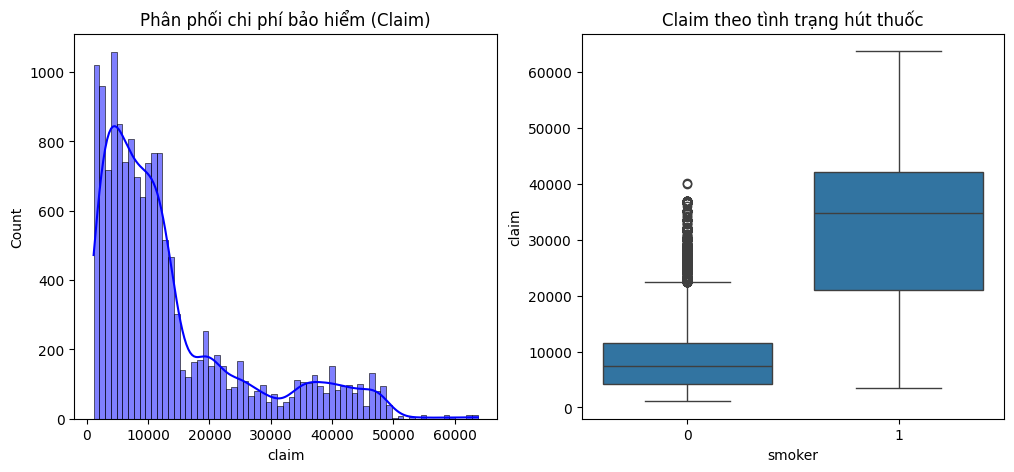


🔬 KIỂM ĐỊNH THỐNG KÊ (Inferential Statistics)
T-test Giới tính (Claim): p-value = 0.0000
T-test Hút thuốc (Claim): p-value = 0.0000

Bảng ANOVA - Bệnh di truyền:
                              sum_sq       df           F  PR(>F)
C(hereditary_diseases)  7.316712e+11      9.0  822.361681     0.0
Residual                1.481877e+12  14990.0         NaN     NaN

🔗 MA TRẬN TƯƠNG QUAN


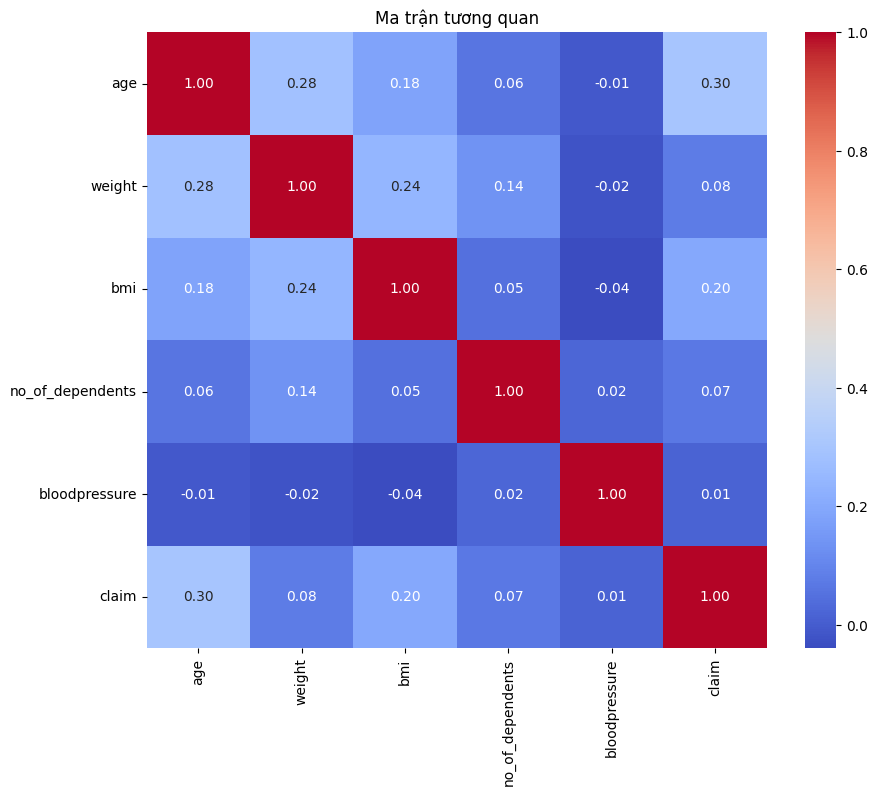


📈 MÔ HÌNH HỒI QUY TUYẾN TÍNH ĐA BIẾN
                            OLS Regression Results                            
Dep. Variable:                  claim   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.717
Method:                 Least Squares   F-statistic:                     5421.
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        14:05:19   Log-Likelihood:            -1.5290e+05
No. Observations:               15000   AIC:                         3.058e+05
Df Residuals:                   14992   BIC:                         3.059e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
In

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:178: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/rdt/transformers/utils.py:194: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data = data.fillna(sentinel).replace({sentinel: None})
/usr/local/lib/python3.12/dist-packages/rdt/transformers/utils.py:194: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In

✅ Đã sinh thêm 5.000 bản ghi synthetic!

📊 SO SÁNH PHÂN PHỐI


/tmp/ipykernel_24984/3394568781.py:137: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['claim'], label='Dữ liệu gốc', shade=True, color='blue')
/tmp/ipykernel_24984/3394568781.py:138: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(synthetic_data['claim'], label='Dữ liệu synthetic', shade=True, color='orange')


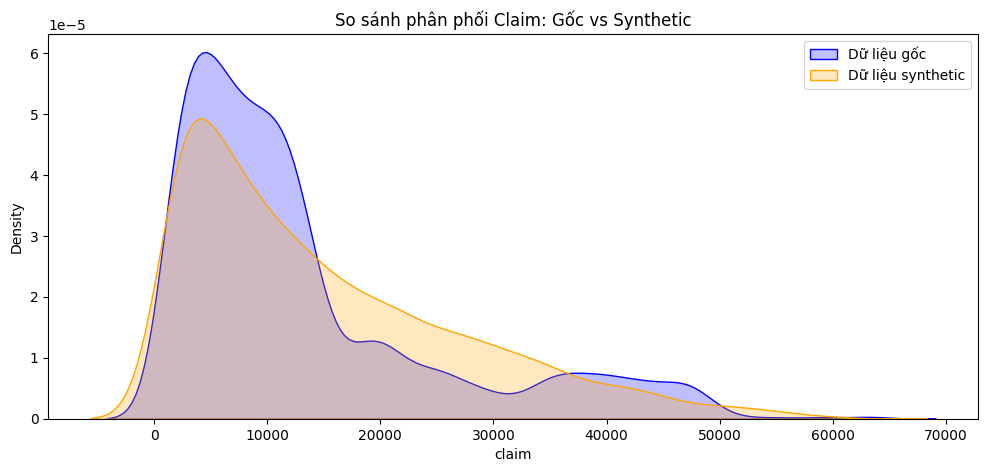

In [ ]:
# ====================== 1. THIẾT LẬP COLAB ======================
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Upload file CSV (chỉ chạy 1 lần)
from google.colab import files
print("📤 Vui lòng upload file: 1651277648862_healthinsurance.csv")
uploaded = files.upload()

# Đọc file (tự động lấy tên file bạn vừa upload)
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
print(f"✅ Đã tải file: {filename} | Số dòng: {len(df)}")

# ====================== 2. LÀM SẠCH DỮ LIỆU ======================
print("\n🔧 Xử lý giá trị thiếu và chuyển kiểu dữ liệu...")

# Imputation bằng median (an toàn với outlier)
df['age'] = df['age'].fillna(df['age'].median())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Chuyển biến phân loại thành category
categorical_cols = ['sex', 'smoker', 'diabetes', 'regular_ex', 'hereditary_diseases']
for col in categorical_cols:
    df[col] = df[col].astype('category')

print("✅ Dữ liệu đã làm sạch. Tổng số dòng:", len(df))
print(df.info())

# ====================== 3. THỐNG KÊ MÔ TẢ ======================
print("\n📊 THỐNG KÊ MÔ TẢ (Descriptive Statistics)")

# Bảng thống kê chi tiết
desc = df[['age', 'bmi', 'bloodpressure', 'claim']].describe()
desc.loc['skew'] = df[['age', 'bmi', 'bloodpressure', 'claim']].skew()
desc.loc['kurt'] = df[['age', 'bmi', 'bloodpressure', 'claim']].kurt()
print(desc)

# Phân bố biến phân loại
print("\nCơ cấu mẫu nghiên cứu (%):")
for col in ['sex', 'smoker', 'diabetes', 'regular_ex']:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True) * 100)

# Biểu đồ
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['claim'], kde=True, color='blue')
plt.title('Phân phối chi phí bảo hiểm (Claim)')

plt.subplot(1, 2, 2)
sns.boxplot(x='smoker', y='claim', data=df)
plt.title('Claim theo tình trạng hút thuốc')
plt.show()

# ====================== 4. THỐNG KÊ SUY LUẬN ======================
print("\n🔬 KIỂM ĐỊNH THỐNG KÊ (Inferential Statistics)")

# T-test: Giới tính
male = df[df['sex'] == 'male']['claim']
female = df[df['sex'] == 'female']['claim']
t_sex, p_sex = stats.ttest_ind(male, female)
print(f"T-test Giới tính (Claim): p-value = {p_sex:.4f}")

# T-test: Hút thuốc
smoker_yes = df[df['smoker'] == 1]['claim']
smoker_no = df[df['smoker'] == 0]['claim']
t_smoke, p_smoke = stats.ttest_ind(smoker_yes, smoker_no)
print(f"T-test Hút thuốc (Claim): p-value = {p_smoke:.4f}")

# ANOVA: Bệnh di truyền
model_anova = ols('claim ~ C(hereditary_diseases)', data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print("\nBảng ANOVA - Bệnh di truyền:")
print(anova_table)

# ====================== 5. TƯƠNG QUAN & HỒI QUY ======================
print("\n🔗 MA TRẬN TƯƠNG QUAN")
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan')
plt.show()

# Hồi quy tuyến tính đa biến
print("\n📈 MÔ HÌNH HỒI QUY TUYẾN TÍNH ĐA BIẾN")
formula = 'claim ~ age + bmi + bloodpressure + C(sex) + C(smoker) + C(diabetes) + regular_ex'
model = ols(formula, data=df).fit()
print(model.summary())

# ====================== 6. KIỂM TRA GIẢ ĐỊNH MÔ HÌNH ======================
print("\n🧪 KIỂM TRA ĐA CỘNG TUYẾN (VIF)")
X = df[['age', 'bmi', 'bloodpressure']]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

# ====================== 7. SINH DỮ LIỆU GIẢ LẬP (SYNTHETIC DATA) ======================
print("\n🧬 SINH DỮ LIỆU GIẢ LẬP - Phần 1: Cài SDV (khuyên dùng)")
!pip install sdv -q

from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df)

# Sinh thêm 5000 dòng
synthetic_data = synthesizer.sample(num_rows=5000)
print(f"✅ Đã sinh thêm 5.000 bản ghi synthetic!")

# ====================== 8. PHƯƠNG PHÁP BOOTSTRAPPING (dự phòng) ======================
def generate_bootstrap(original_df, n_extra=5000):
    new_data = original_df.sample(n=n_extra, replace=True).reset_index(drop=True)
    for col in ['age', 'bmi', 'bloodpressure', 'claim']:
        noise = np.random.normal(0, original_df[col].std() * 0.02, n_extra)
        new_data[col] = (new_data[col] + noise).clip(lower=original_df[col].min())
    return new_data

# df_expanded = generate_bootstrap(df, 5000)
# full_df = pd.concat([df, df_expanded], ignore_index=True)

# ====================== 9. SO SÁNH DỮ LIỆU GỐC VS SYNTHETIC ======================
print("\n📊 SO SÁNH PHÂN PHỐI")
plt.figure(figsize=(12, 5))
sns.kdeplot(df['claim'], label='Dữ liệu gốc', shade=True, color='blue')
sns.kdeplot(synthetic_data['claim'], label='Dữ liệu synthetic', shade=True, color='orange')
plt.title('So sánh phân phối Claim: Gốc vs Synthetic')
plt.legend()
plt.show()
